## Experiment No: 5
## Experiment Title: Ridge and Lasso Regularization - Influence on Overfitting and Multicollinearity

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Step 2: Load the DataSet

In [2]:
diabetes = load_diabetes(as_frame=True)
df       = diabetes.frame

print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Step 3: Check MultiCollinearity Among Features 

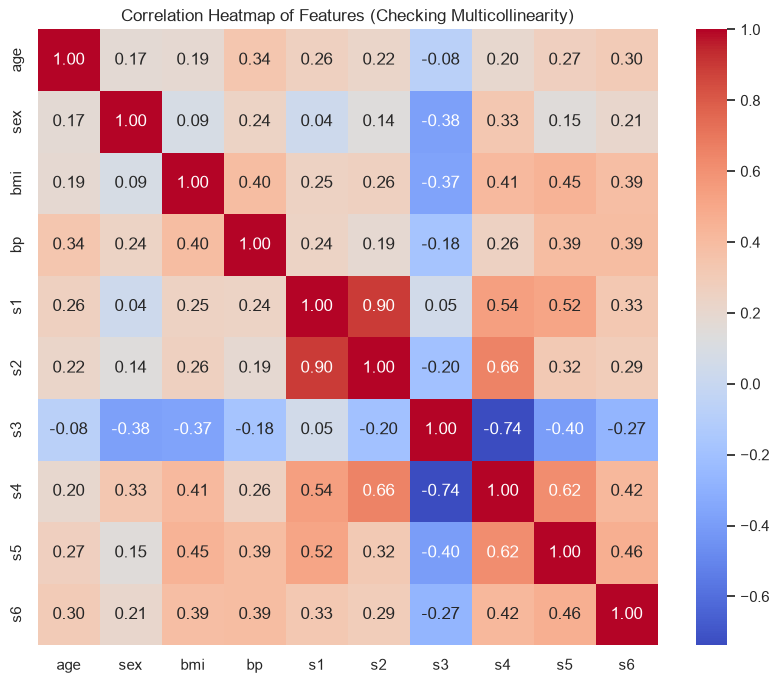

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop("target", axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features (Checking Multicollinearity)")
plt.show()

### step 4: Create Polynomial Features to Increase MultiCollinearlty

In [4]:
x = df.drop("target", axis=1)
y = df["target"]

poly   = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

print("Original number of features                   : ", x.shape[1])
print("Number of features after polynomial expansion : ", x_poly.shape[1])

Original number of features                   :  10
Number of features after polynomial expansion :  65


### Step 5: Scale the Features

In [5]:
scaler = StandardScaler()
x_poly_scaled = scaler.fit_transform(x_poly)

print("Feature scaling completed. Mean approx 0, Std Dev. approx 1 for each feature.")

Feature scaling completed. Mean approx 0, Std Dev. approx 1 for each feature.


### Step 6: Split Data into Training and Testing Sets

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x_poly_scaled, y, test_size=0.3, random_state=33
)

print("Training Set Size: ", x_train.shape)
print("Testing  Set Size: ", x_test.shape)

Training Set Size:  (309, 65)
Testing  Set Size:  (133, 65)


### Step 7: Train Linear, Ridgem Lasso Regression Models 

In [7]:
# Plain Linear Regression -> No regualrization, prone to overfitting with many correlated features 
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Ridge Regression -> Adds L2 penalty, shrinks coefficients but keeps all features
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)

# Lasso Regression -> Adds L1 penalty, can shrink some coefficients exactly to zero
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train, y_train)

print("All Three Models Trained Successfully...")


All Three Models Trained Successfully...


### Step 8: Evaluate and Compare the Models

In [8]:
def evaluate_model(name, model, x_train, y_train, x_test, y_test):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"{name}")
    print(f"  Train MSE : {train_mse:.2f}")
    print(f"  Test MSE  : {test_mse:.2f}")
    print(f"  Test R2   : {test_r2:.4f}")
    print("-" * 40)

    return train_mse, test_mse, test_r2

results = {}
results["Linear"] = evaluate_model("Linear Regression (No Regularization)", linear_model, x_train, y_train, x_test, y_test)
results["Ridge"]  = evaluate_model("Ridge Regression (L2 Penalty)", ridge_model, x_train, y_train, x_test, y_test)
results["Lasso"]  = evaluate_model("Lasso Regression (L1 Penalty)", lasso_model, x_train, y_train, x_test, y_test)


Linear Regression (No Regularization)
  Train MSE : 2198.63
  Test MSE  : 4176.39
  Test R2   : 0.2339
----------------------------------------
Ridge Regression (L2 Penalty)
  Train MSE : 2234.68
  Test MSE  : 3775.69
  Test R2   : 0.3074
----------------------------------------
Lasso Regression (L1 Penalty)
  Train MSE : 2257.85
  Test MSE  : 3716.47
  Test R2   : 0.3182
----------------------------------------


### Step 9: Compare Model Performance in a Table

In [9]:
comparison_df = pd.DataFrame(results, index=["Train MSE", "Test MSE", "Test R2"]).T
print(comparison_df)

          Train MSE     Test MSE   Test R2
Linear  2198.625113  4176.389255  0.233862
Ridge   2234.676991  3775.686115  0.307369
Lasso   2257.847688  3716.468965  0.318232


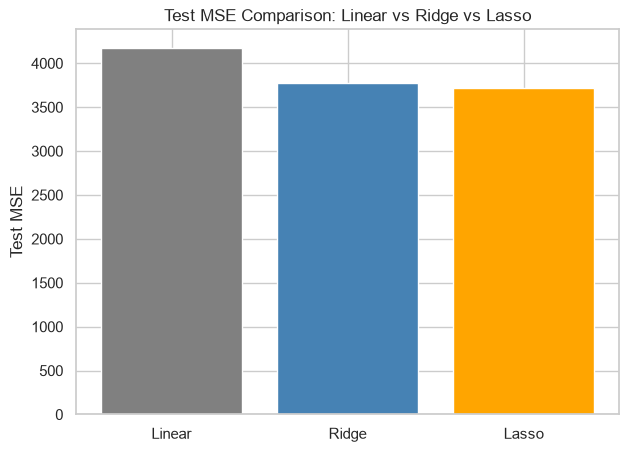

In [10]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_df.index, comparison_df["Test MSE"], color=["gray", "steelblue", "orange"])
plt.ylabel("Test MSE")
plt.title("Test MSE Comparison: Linear vs Ridge vs Lasso")
plt.show()

### Step 10: Observe the Effect on Coefficients(Overfitting & Multicolliearity)

In [11]:
coef_df = pd.DataFrame({
    "Linear" : linear_model.coef_,
    "Ridge"  : ridge_model.coef_,
    "Lasso"  : lasso_model.coef_
})

print("Number of near-zero coefficients (|coef| < 0.01): ")
print("Linear: ", (np.abs(coef_df['Linear']) < 0.01).sum())
print("Ridge : ", (np.abs(coef_df['Ridge'])  < 0.01).sum())
print("Lasso : ", (np.abs(coef_df['Lasso'])  < 0.01).sum())

Number of near-zero coefficients (|coef| < 0.01): 
Linear:  0
Ridge :  0
Lasso :  13


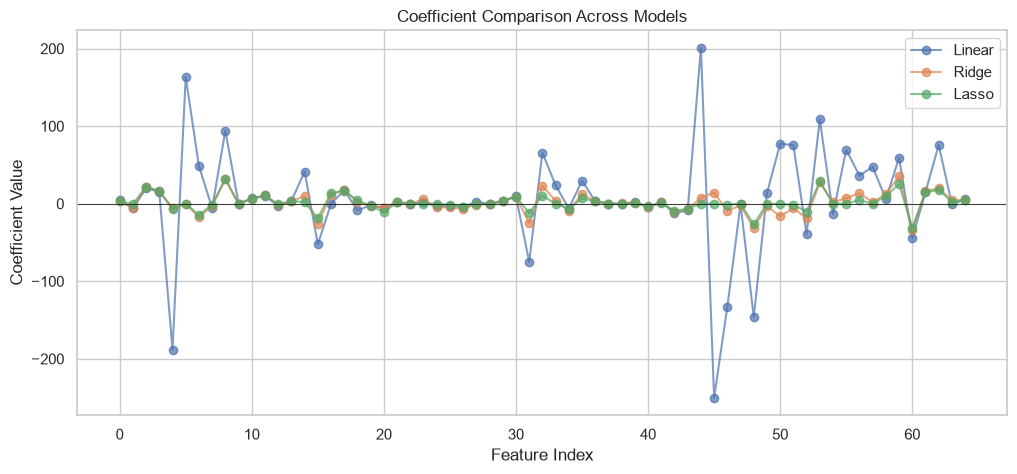

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(coef_df["Linear"].values, marker='o', label="Linear", alpha=0.7)
plt.plot(coef_df["Ridge"].values , marker='o', label="Ridge" , alpha=0.7)
plt.plot(coef_df["Lasso"].values , marker='o', label="Lasso" , alpha=0.7)
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison Across Models")
plt.legend()
plt.axhline(0, color="black", linewidth=0.5)
plt.show()

### Step 11: Final Output

In [13]:
print("Experiment Completed Successfully")
print("\nFinal Model Comparison:")
print(comparison_df)


Experiment Completed Successfully

Final Model Comparison:
          Train MSE     Test MSE   Test R2
Linear  2198.625113  4176.389255  0.233862
Ridge   2234.676991  3775.686115  0.307369
Lasso   2257.847688  3716.468965  0.318232
